# OuviSearch — Entrega 2: Detecção de Duplicatas

**Desafio:** Ouvidoria Inteligente - Triagem Semântica de Manifestações Cidadãs <br>
**Disciplina:** Tendências em Ciência da Computação <br>
**Autor:** Pedro Nícollas Pereira Leon Lopes <br>

Este notebook implementa `detectar_duplicatas(textos, limiar=0.85)`, calcula a matriz de similaridade completa (heatmap), lista os pares encontrados e compara com as duplicatas reais conhecidas do dataset (definidas na criação do corpus).

## 1. Carregamento e representação vetorial

In [1]:
# Conjunto de importações
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

with open("../data/manifestacoes.json", encoding="utf-8") as f:
    data = json.load(f)

manifestacoes = data["manifestacoes"]
ids = [m["id"] for m in manifestacoes]
textos = [m["texto"] for m in manifestacoes]
N = len(manifestacoes)

# Duplicatas reais conhecidas (definidas na construção do corpus sintético - ver README.md/relatório)
DUPLICATAS_REAIS = [frozenset(("M003", "M017")), frozenset(("M008", "M022")), frozenset(("M014", "M029"))]

print(f"{N} manifestações | {len(DUPLICATAS_REAIS)} pares de duplicatas reais conhecidos")

40 manifestações | 3 pares de duplicatas reais conhecidos


In [2]:
def carregar_modelo_embeddings(nome="paraphrase-multilingual-MiniLM-L12-v2"):
    try:
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer(nome), True
    except Exception as e:
        print(f"[aviso] sentence-transformers indisponível ({e}); usando fallback TF-IDF+SVD.")
        return None, False


def gerar_embeddings(textos, nome_modelo="paraphrase-multilingual-MiniLM-L12-v2"):
    modelo, ok = carregar_modelo_embeddings(nome_modelo)
    if ok:
        return np.asarray(modelo.encode(textos, normalize_embeddings=True)), True
    vectorizer = TfidfVectorizer(lowercase=True, strip_accents="unicode")
    tfidf_matrix = vectorizer.fit_transform(textos)
    n_components = min(30, tfidf_matrix.shape[1] - 1, tfidf_matrix.shape[0] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    denso = svd.fit_transform(tfidf_matrix)
    normas = np.linalg.norm(denso, axis=1, keepdims=True)
    normas[normas == 0] = 1
    return denso / normas, False


embeddings, usou_embeddings_reais = gerar_embeddings(textos)
print(f"Embeddings: {embeddings.shape} (modelo real: {usou_embeddings_reais})")

/tmp/ouvisearch_test_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4781.11it/s]

Embeddings: (40, 384) (modelo real: True)


## 2. Função `detectar_duplicatas`

In [3]:
def detectar_duplicatas(textos, limiar=0.85, modelo_nome="paraphrase-multilingual-MiniLM-L12-v2"):
    """Recebe a lista de textos das manifestações e retorna todos os pares (i, j, score)
    com similaridade de cosseno >= limiar, com i < j (índices posicionais em `textos`)."""
    vetores, _ = gerar_embeddings(textos, modelo_nome)
    sim = cosine_similarity(vetores)
    n = len(textos)
    pares = []
    for i in range(n):
        for j in range(i + 1, n):
            if sim[i, j] >= limiar:
                pares.append((i, j, float(sim[i, j])))
    pares.sort(key=lambda x: -x[2])
    return pares, sim


pares_085, matriz_sim = detectar_duplicatas(textos, limiar=0.85)
print(f"Com limiar=0.85 (padrão do enunciado): {len(pares_085)} pares encontrados.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3373.98it/s]

Com limiar=0.85 (padrão do enunciado): 0 pares encontrados.


## 3. Matriz de similaridade completa (heatmap)

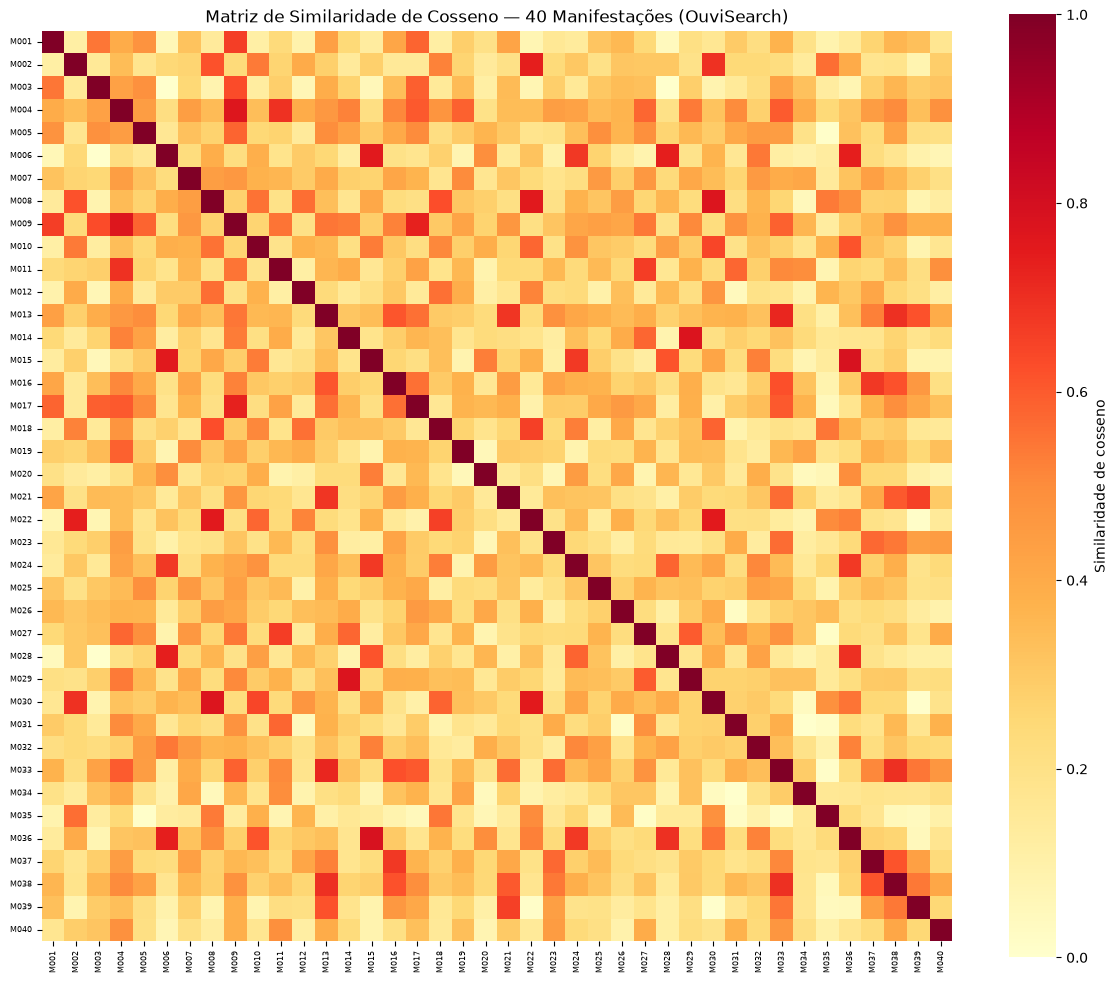

In [4]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matriz_sim, xticklabels=ids, yticklabels=ids, cmap="YlOrRd",
            vmin=0, vmax=1, square=True, cbar_kws={"label": "Similaridade de cosseno"}, ax=ax)
ax.set_title("Matriz de Similaridade de Cosseno — 40 Manifestações (OuviSearch)")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig("../assets/heatmap_similaridade.png", dpi=150)
plt.show()

## 4. Calibração do limiar

Com o limiar padrão de **0.85** do enunciado, **nenhum par** é encontrado. <br> 
O maior score do corpus com o modelo real é ~ 0.79. <br>
Antes de escolher outro valor, vamos olhar para a distribuição real das similaridades, como sugere o próprio enunciado da entrega 2 e para a posição no ranking de todos os 780 pares, de cada duplicata que sabemos existir.

In [5]:
def eh_duplicata_real(id_a, id_b):
    """Diz se as manifestações A e B formam um par de duplicata real (em qualquer ordem)."""
    for par_real in DUPLICATAS_REAIS:
        if id_a in par_real and id_b in par_real:
            return True
    return False


# Monta uma linha para cada par de manifestações (40 manifestações -> 780 pares)
linhas = []
total = len(textos)

for i in range(total):
    # j começa em i + 1 para não comparar uma manifestação com ela mesma
    # nem repetir o mesmo par nas duas ordens: (A, B) e (B, A)
    for j in range(i + 1, total):
        linhas.append({
            "manifestacao_a": ids[i],
            "manifestacao_b": ids[j],
            "similaridade": matriz_sim[i, j],
            "duplicata_real": eh_duplicata_real(ids[i], ids[j]),
        })

# Ordena do par mais parecido para o menos parecido e numera a posição no ranking
tabela_pares = pd.DataFrame(linhas)
tabela_pares = tabela_pares.sort_values("similaridade", ascending=False)
tabela_pares = tabela_pares.reset_index(drop=True)
tabela_pares["posicao"] = tabela_pares.index + 1

print(f"{len(tabela_pares)} pares comparados.")

780 pares comparados.


In [6]:
# Os 10 pares mais parecidos.
# A coluna "duplicata_real" mostra se o par é uma das duplicatas que conhecemos.
tabela_pares.head(10).round(4)

,manifestacao_a,manifestacao_b,similaridade,duplicata_real,posicao
0,M015,M036,0.7889,False,1
1,M014,M029,0.7769,True,2
2,M008,M030,0.7708,False,3
3,M004,M009,0.7687,False,4
4,M008,M022,0.7547,True,5
5,M006,M015,0.7540,False,6
6,M022,M030,0.7534,False,7
7,M006,M036,0.7414,False,8
8,M002,M022,0.7388,False,9
9,M006,M028,0.7386,False,10


In [7]:
# Percentil 99 = valor de similaridade que só 1% dos pares consegue superar
for percentil in (90, 95, 97, 99):
    valor = tabela_pares["similaridade"].quantile(percentil / 100)
    print(f"Percentil {percentil}: {valor:.4f}")

# Em que posição do ranking estão as duplicatas reais?
print(f"\nPosição das duplicatas reais entre os {len(tabela_pares)} pares:")
tabela_pares[tabela_pares["duplicata_real"]].round(4)

Percentil 90: 0.5282
Percentil 95: 0.6024
Percentil 97: 0.6614
Percentil 99: 0.7393

Posição das duplicatas reais entre os 780 pares:


,manifestacao_a,manifestacao_b,similaridade,duplicata_real,posicao
1,M014,M029,0.7769,True,2
4,M008,M022,0.7547,True,5
42,M003,M017,0.5926,True,43


In [8]:
# Varredura de limiares: para cada limiar, quantos pares são marcados e quantos acertam?
resultados = []

for limiar in (0.85, 0.80, 0.75, 0.70, 0.65):
    # pares cuja similaridade é maior ou igual ao limiar
    marcados = tabela_pares[tabela_pares["similaridade"] >= limiar]

    acertos = int(marcados["duplicata_real"].sum())    # marcados que SÃO duplicatas reais (TP)
    erros = len(marcados) - acertos                    # marcados que NÃO são duplicatas (FP)
    perdidas = len(DUPLICATAS_REAIS) - acertos         # duplicatas reais que não foram marcadas (FN)

    resultados.append({
        "Limiar": limiar,
        "Pares marcados": len(marcados),
        "TP": acertos,
        "FP": erros,
        "FN": perdidas,
    })

pd.DataFrame(resultados)

,Limiar,Pares marcados,TP,FP,FN
0,0.85,0,0,0,3
1,0.80,0,0,0,3
2,0.75,7,2,5,1
3,0.70,12,2,10,1
4,0.65,26,2,24,1


O limiar **0.75** é o mais alto que já captura duas das três duplicatas reais (M014×M029 e M008×M022). Acima dele nada é detectado, e abaixo dele o número de falsos positivos explode (0.70 já marca 12 pares, 0.65 marca 26). <br>
Vamos usá-lo como limiar calibrado. 

In [9]:
LIMIAR_CALIBRADO = 0.75
pares_calibrados, _ = detectar_duplicatas(textos, limiar=LIMIAR_CALIBRADO)

df_pares = pd.DataFrame([
    {"Par": f"{ids[i]} x {ids[j]}", "Similaridade": round(s, 4)}
    for i, j, s in pares_calibrados
])
print(f"Com limiar={LIMIAR_CALIBRADO}: {len(pares_calibrados)} pares encontrados.")
df_pares

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4421.84it/s]

Com limiar=0.75: 7 pares encontrados.


,Par,Similaridade
0,M015 x M036,0.7889
1,M014 x M029,0.7769
2,M008 x M030,0.7708
3,M004 x M009,0.7687
4,M008 x M022,0.7547
5,M006 x M015,0.7540
6,M022 x M030,0.7534


## 5. Análise de falsos positivos e falsos negativos

In [10]:
pares_detectados = {frozenset((ids[i], ids[j])) for i, j, _ in pares_calibrados}
duplicatas_reais = set(DUPLICATAS_REAIS)

verdadeiros_positivos = pares_detectados & duplicatas_reais
falsos_positivos = pares_detectados - duplicatas_reais
falsos_negativos = duplicatas_reais - pares_detectados

def fmt(pares):
    return [tuple(sorted(p)) for p in pares] or ["(nenhum)"]

print(f"Verdadeiros positivos ({len(verdadeiros_positivos)}): {fmt(verdadeiros_positivos)}")
print(f"Falsos positivos ({len(falsos_positivos)}):        {fmt(falsos_positivos)}")
print(f"Falsos negativos ({len(falsos_negativos)}):        {fmt(falsos_negativos)}")

precisao = len(verdadeiros_positivos) / len(pares_detectados) if pares_detectados else 0
recall = len(verdadeiros_positivos) / len(duplicatas_reais) if duplicatas_reais else 0
print(f"\nPrecisão: {precisao:.2f} | Recall: {recall:.2f}")

categorias_por_id = {m["id"]: m["categoria_oficial"] for m in manifestacoes}
print("\nCategoria oficial dos falsos positivos:")
for par in falsos_positivos:
    a, b = sorted(par)
    print(f"  {a} ({categorias_por_id[a]}) x {b} ({categorias_por_id[b]})")

Verdadeiros positivos (2): [('M014', 'M029'), ('M008', 'M022')]
Falsos positivos (5):        [('M004', 'M009'), ('M008', 'M030'), ('M006', 'M015'), ('M022', 'M030'), ('M015', 'M036')]
Falsos negativos (1):        [('M003', 'M017')]

Precisão: 0.29 | Recall: 0.67

Categoria oficial dos falsos positivos:
  M004 (segurança) x M009 (infraestrutura)
  M008 (saúde) x M030 (saúde)
  M006 (educação) x M015 (educação)
  M022 (saúde) x M030 (saúde)
  M015 (educação) x M036 (educação)


## 6. Discussão Final

Com o limiar calibrado em **0.75** (Ao invés do padrão, 0.85), o detector marca 7 pares e encontra **2 dos 3 pares reais** (M014×M029 e M008×M022), com **precisão ≈ 0.29** e **recall ≈ 0.67**. Os erros aparecem nos dois sentidos:

- **Falso negativo (M003 × M017):** 

  Mesmo com embeddings reais, essa duplicata (score ≈ 0.59) fica só na **43ª posição** entre os 780 pares, bem abaixo de muitos pares que não são duplicatas. Como o par é uma paráfrase sem palavras em comum ("buraco" × "esburacado", em avenidas/bairros diferentes), o modelo reconhece a relação, mas não com a intensidade de uma reescrita quase literal, como M014 × M029. <br>
  Para detectá-lo, seria preciso baixar o limiar para ~ 0.59, que por sua vez, marcaria dezenas de pares como duplicatas.


- **Falsos positivos (M015×M036, M008×M030, M006×M015, M022×M030, M004×M009):** 

  Quatro deles são pares do **mesmo tema, mas problemas distintos**: M015 e M036 são duas escolas diferentes de Campina Grande sem merenda (score 0.79, *maior* que o de qualquer duplicata real!); <br>
  
  M008 e M030 são dois problemas de saúde em Campina Grande (falta de médico num posto × falta de leitos no hospital municipal). <br>
  
  O quinto, M004×M009, é o único que cruza categorias (segurança × infraestrutura): Ambos são relatos longos que citam iluminação pública apagada e falta de resposta do poder público. Um modelo de paráfrase mede proximidade de **assunto**, não identidade de **denúncia**: Duas reclamações sobre o mesmo tipo de falha em lugares diferentes ficam tão próximas quanto duas descrições do mesmo fato.

**Conclusão:** 

  O limiar de 0.85 sugerido no enunciado é alto demais para este modelo e este corpus (o teto é ≈ 0.79), e nenhum limiar único separa bem duplicatas de manifestações apenas do mesmo tema: Acima de 0.75 se perde recall, abaixo dele a precisão despenca. <br>
  A similaridade de cosseno sozinha é uma boa **triagem** (leva o revisor humano aos ~7 pares mais suspeitos em vez de 780), mas não uma decisão automática de descarte. Melhorias naturais seriam combinar o score com sinais adicionais (mesmo bairro/logradouro, mesma categoria oficial, datas próximas) ou usar um cross-encoder para reavaliar os pares candidatos.